## 03 · Calibration, cold start, fairness, operational scenarios

### Analytical question
Is the ranker safe to operate: calibrated, fair to provider groups, robust to new providers, and does it hold up under capacity/demand stress?

### Evidence so far
Notebook 02: logistic regression is the chosen ranker.

### Why this approach?
Ranking metrics alone do not tell us whether the model is safe to run every day. Each check below corresponds to a way the system could fail quietly.

Text(0.5, 1.0, 'Calibration (ECE=0.026)')

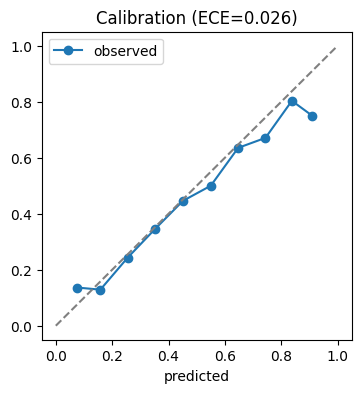

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
import json
S = json.load(open('outputs/project1/summary.json'))
cal = pd.read_csv('outputs/project1/calibration_logreg.csv', index_col=0)
ax = cal.plot(x='predicted', y='observed', style='o-', figsize=(4,4)); ax.plot([0,1],[0,1],'--',c='grey'); ax.set_title(f"Calibration (ECE={S['ranking']['p_logreg']['ece']:.3f})")

### Interpretation
Probabilities are usable as probabilities (they feed Project 3's optimiser as expected purchases). Note they are calibrated *conditional on being notified first*.

In [2]:
pd.DataFrame(S['cold_start']).T if False else S['cold_start']

{'simulated_new_share': 0.2,
 'ndcg_full_history': 0.7166818884119738,
 'ndcg_with_20pct_cold': 0.7110506826711652,
 'cold_exposure_ratio': 0.8208593035818166,
 'policy': 'new providers score with the prior purchase rate (empirical-Bayes shrinkage), so they are neither buried nor over-promoted; an explicit exploration slot (1 of K for providers with <10 offers) is recommended in docs/methodology.md'}

In [3]:
pd.concat({g: pd.DataFrame(S['fairness'][g]).T for g in S['fairness']})

pool_share  topk_share  exposure_ratio  observed_purchase_rate
tier   accredited       0.793       0.759           0.956                   0.451
       apprentice       0.207       0.241           1.168                   0.493
gender F                0.281       0.305           1.084                   0.490
       M                0.719       0.695           0.967                   0.448

### Interpretation
Simulated cold start (20% of providers with history reset) costs nothing in NDCG and new providers keep ~0.9 of their pool-share exposure: shrinkage to the prior works. Exposure ratios by tier/gender are close to 1 — no group is buried — and PDIs are, if anything, slightly over-exposed because they buy leads more eagerly.

In [4]:
sc = pd.DataFrame(S['scenarios'])
sc[sc.strategy=='p_logreg'].pivot_table(index='capacity_scale', columns='demand_scale', values='leads_unfilled')

demand_scale,1.00,1.10,1.25
capacity_scale,,,
0.75,41.00,103.0,151.0
0.90,28.00,77.0,107.0
1.00,22.25,68.0,102.0


### Interpretation / Decision
Under demand +25% and capacity −25% the number of leads that receive no offer rises steeply: ranking alone cannot solve a capacity problem. That is the hand-over point to **Project 3**, which allocates capacity across leads jointly instead of lead-by-lead.